# Delta Hedging

## Libraries Import

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sys.path.append('..')

from src.config_loader import load_config
from src.stochastic_engines import GBMModel, MertonJumpDiffusion
from src.analytics import (
    bsm_price,
    bsm_delta,
)

np.set_printoptions(suppress=True, precision=6)

## Market Configuration

In [2]:
config = load_config()

r = float(config.market_params.r)
sigma_bsm = float(config.market_params.sigma)
S0 = float(config.market_params.S0)

T_sim = float(config.simulation.T_sim)
total_n_steps = int(config.market_params.n_steps)
dt = T_sim / total_n_steps

hedge_T = float(config.option_params.T_maturity)
assert T_sim >= hedge_T, f"T_sim ({T_sim}) must be >= T_maturity ({hedge_T}) for truncation."
n_steps = int(round(hedge_T / dt))
t_grid = np.arange(n_steps + 1) * dt

def _truncate_paths(paths: np.ndarray, n_steps: int) -> np.ndarray:
    return np.asarray(paths[:, : n_steps + 1], dtype=float)

print(f"dt={dt:.6f}, hedge_T={hedge_T}, n_steps={n_steps}, n_paths={config.simulation.n_paths}")

dt=0.003968, hedge_T=2.0, n_steps=504, n_paths=10000


## Loading Simulation

In [3]:
# Paths access
paths_file = Path("..") / "data" / "simulated_paths.npz"

if paths_file.exists():
    data = np.load(paths_file)
    gbm_paths_full = np.asarray(data["gbm"], dtype=float)
    mjd_paths_full = np.asarray(data["merton"], dtype=float)

    # Error if dt mismatch
    dt_file = float(data.get("dt", dt))
    if not np.isclose(dt_file, dt):
        print(f"Warning: dt in file ({dt_file}) != config dt ({dt}).")

    print("Loaded simulated paths...")
else:
    print("Paths file not found...")
    gbm_paths_full = GBMModel(config).generate_paths()
    mjd_paths_full = MertonJumpDiffusion(config).generate_paths()

# Truncation to hedge horizon
gbm_paths = _truncate_paths(gbm_paths_full, n_steps=n_steps)
mjd_paths = _truncate_paths(mjd_paths_full, n_steps=n_steps)

assert gbm_paths.shape == mjd_paths.shape
print("paths shape:", gbm_paths.shape)

Loaded simulated paths...
paths shape: (10000, 505)


## Volatility Smile

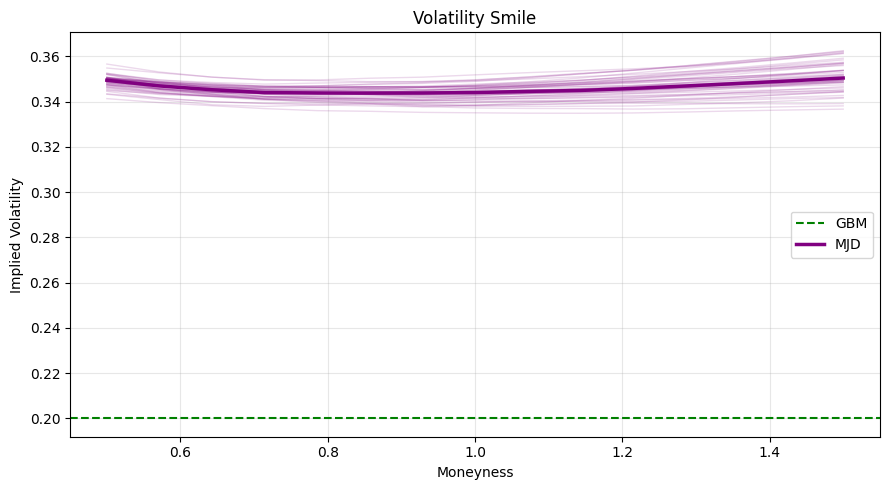

In [4]:
from scipy.optimize import brentq

T_smile = hedge_T
option_type = config.option_params.option_type
S0_smile = S0
r_smile = r

K_grid = np.linspace(0.5 * S0_smile, 1.5 * S0_smile, 15)
ST_mjd = mjd_paths[:, -1]
discount = np.exp(-r_smile * T_smile)

def implied_vol(price, S, K, T, r, option_type="call", tol=1e-6):
    if price <= 0.0:
        return np.nan

    def _f(sigma):
        return bsm_price(S, K, T, r, sigma, option_type=option_type) - price

    try:
        return brentq(_f, 1e-4, 5.0, xtol=tol)
    except ValueError:
        return np.nan

def smile_from_sample(ST_sample):
    prices = []
    for K in K_grid:
        payoff = (np.maximum(ST_sample - K, 0.0) if option_type == "call" else np.maximum(K - ST_sample, 0.0))
        prices.append(discount * np.mean(payoff))
    prices = np.asarray(prices, dtype=float)
    iv = np.array([
        implied_vol(p, S0_smile, K, T_smile, r_smile, option_type=option_type)
        for p, K in zip(prices, K_grid)
    ])
    return iv

rng = np.random.default_rng(123)
n_paths = ST_mjd.shape[0]
n_boot = 50
boot_iv = []

plt.figure(figsize=(9, 5))

for b in range(n_boot):
    idx = rng.choice(n_paths, size=n_paths, replace=True)
    iv = smile_from_sample(ST_mjd[idx])
    boot_iv.append(iv)
    plt.plot(K_grid / S0_smile, iv, color="purple", alpha=0.15, lw=1)

boot_iv = np.asarray(boot_iv)
iv_med = np.nanmedian(boot_iv, axis=0)

plt.axhline(sigma_bsm, linestyle="--", label="GBM", color="green")
plt.plot(K_grid / S0_smile, iv_med, color="purple", lw=2.5, label="MJD")
plt.xlabel("Moneyness")
plt.ylabel("Implied Volatility")
plt.title("Volatility Smile")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Hedging Contract

In [5]:
K0 = float(config.option_params.K)
option_type = config.option_params.option_type

## Delta Hedge Engine

In [6]:
def time_to_maturity_grid(T: float, dt: float, n_steps: int) -> np.ndarray:
    tau = T - np.arange(n_steps + 1) * dt
    return np.maximum(tau, 0.0)


tau_grid = time_to_maturity_grid(hedge_T, dt=dt, n_steps=n_steps)


def run_delta_hedge(
    paths: np.ndarray,
    *,
    r: float,
    sigma: float,
    dt: float,
    tau_grid: np.ndarray,
    K0: float,
    option_type: str = "call",
) -> dict:
    paths = np.asarray(paths, dtype=float)
    n_paths, n_steps_plus_1 = paths.shape
    n_steps = n_steps_plus_1 - 1

    assert tau_grid.shape[0] == n_steps_plus_1

    # Holdings
    xS = np.zeros((n_paths, n_steps_plus_1))  # Stock
    B = np.zeros((n_paths, n_steps_plus_1))   # Bank account

    # Liability model price
    C0 = np.zeros((n_paths, n_steps_plus_1))

    # Stepwise PnL components
    pnl_stock = np.zeros((n_paths, n_steps))
    pnl_cash = np.zeros((n_paths, n_steps))
    pnl_liability = np.zeros((n_paths, n_steps))
    pnl_hedged = np.zeros((n_paths, n_steps))

    # Initial hedge
    S0_vec = paths[:, 0]
    tau0 = float(tau_grid[0])

    C0[:, 0] = bsm_price(S0_vec, K0, tau0, r, sigma, option_type=option_type)
    D0 = bsm_delta(S0_vec, K0, tau0, r, sigma, option_type=option_type)

    xS[:, 0] = D0
    B[:, 0] = C0[:, 0] - xS[:, 0] * S0_vec

    growth = float(np.exp(r * dt))

    for i in range(n_steps):
        S_i = paths[:, i]
        S_ip1 = paths[:, i + 1]
        tau_i = float(tau_grid[i])
        tau_ip1 = float(tau_grid[i + 1])

        # Current liability price
        if i > 0:
            C0[:, i] = bsm_price(S_i, K0, tau_i, r, sigma, option_type=option_type)

        # Next liability price and delta
        C0_ip1 = bsm_price(S_ip1, K0, tau_ip1, r, sigma, option_type=option_type)
        D0_ip1 = bsm_delta(S_ip1, K0, tau_ip1, r, sigma, option_type=option_type)

        # PnL components
        pnl_stock[:, i] = xS[:, i] * (S_ip1 - S_i)
        pnl_cash[:, i] = B[:, i] * (growth - 1.0)
        pnl_liability[:, i] = (C0_ip1 - C0[:, i])

        pnl_hedged[:, i] = pnl_stock[:, i] + pnl_cash[:, i] - pnl_liability[:, i]

        # Portfolio before re-hedging
        V_pre = xS[:, i] * S_ip1 + B[:, i] * growth

        # Re-hedge portfolio position
        xS[:, i + 1] = D0_ip1
        C0[:, i + 1] = C0_ip1
        B[:, i + 1] = V_pre - xS[:, i + 1] * S_ip1

    # Terminal portfolio value and hedge errors
    V = xS * paths + B
    hedge_error = V - C0

    payoff = (
        np.maximum(paths[:, -1] - K0, 0.0)
        if option_type == "call"
        else np.maximum(K0 - paths[:, -1], 0.0)
    )
    terminal_error_vs_payoff = V[:, -1] - payoff

    return {
        "paths": paths,
        "V": V,
        "C0": C0,
        "xS": xS,
        "B": B,
        "hedge_error": hedge_error,
        "terminal_error_vs_payoff": terminal_error_vs_payoff,
        "pnl_stock": pnl_stock,
        "pnl_cash": pnl_cash,
        "pnl_liability": pnl_liability,
        "pnl_hedged": pnl_hedged,
    }


def hedge_summary(err):
    err = np.asarray(err, dtype=float)
    return pd.Series({
        "avg_error": float(np.mean(err)),
        "std_error": float(np.std(err, ddof=1)),
        "rmse": float(np.sqrt(np.mean(err**2))),
        "var_99": float(-np.quantile(err, 0.01)),
        "miss_50": float(np.quantile(err, 0.50)),
        "gain_99": float(np.quantile(err, 0.99)),
    })

## Running Hedge

In [7]:
gbm_res = run_delta_hedge(
    gbm_paths,
    r=r,
    sigma=sigma_bsm,
    dt=dt,
    tau_grid=tau_grid,
    K0=K0,
    option_type=option_type,
)

mjd_res = run_delta_hedge(
    mjd_paths,
    r=r,
    sigma=sigma_bsm,
    dt=dt,
    tau_grid=tau_grid,
    K0=K0,
    option_type=option_type,
)

gbm_term = gbm_res["terminal_error_vs_payoff"]
mjd_term = mjd_res["terminal_error_vs_payoff"]

summary = pd.DataFrame({
    "GBM": hedge_summary(gbm_term),
    "MJD": hedge_summary(mjd_term),
})

summary

,GBM,MJD
avg_error,0.001544,-7.933569
std_error,0.432425,7.943993
rmse,0.432406,11.226853
var_99,1.178343,37.580684
miss_50,0.001774,-5.731955
gain_99,1.122740,0.317374


## Hedge Error Analysis

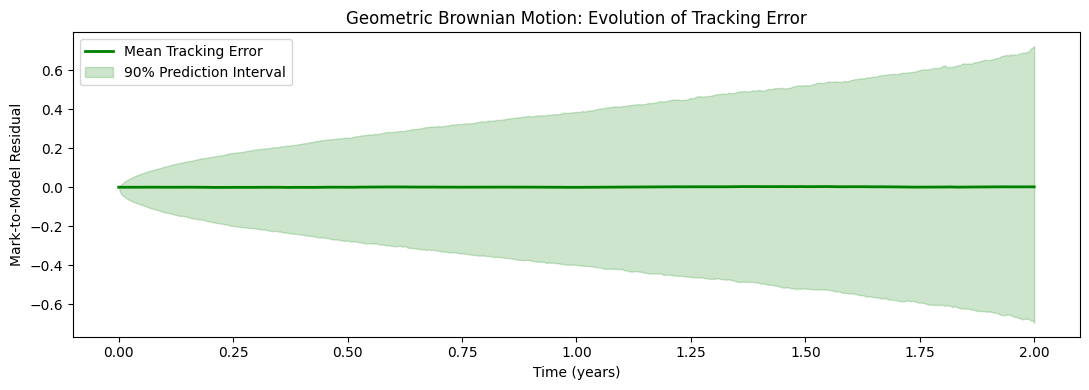

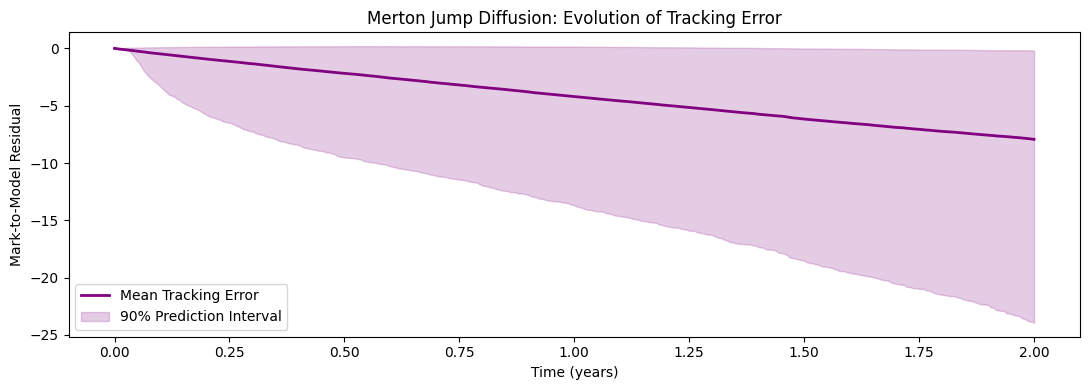

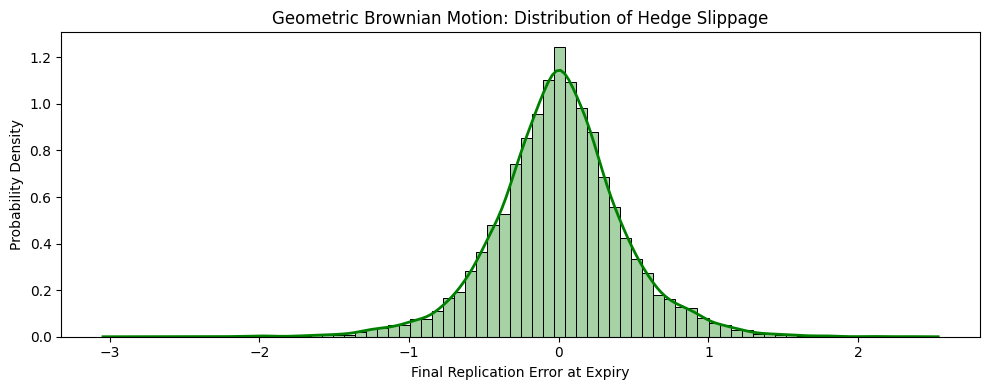

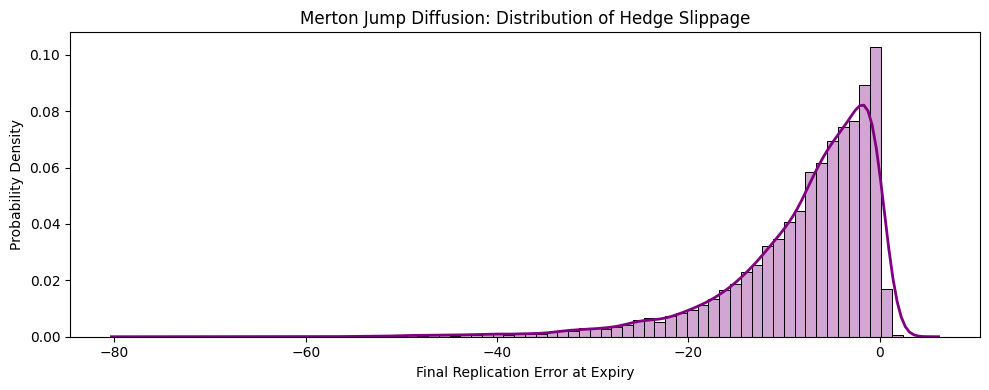

In [8]:
def plot_error_timeseries(res: dict, title: str, *, t_grid: np.ndarray, color: str):
    E = res["hedge_error"]
    q = np.quantile(E, [0.05, 0.5, 0.95], axis=0)
    mean = E.mean(axis=0)

    plt.figure(figsize=(11, 4))
    plt.plot(t_grid, mean, lw=2.0, label="Mean Tracking Error", color=color)
    plt.fill_between(t_grid, q[0], q[2], alpha=0.2, label="90% Prediction Interval", color=color)
    
    plt.title(title)
    plt.xlabel("Time (years)")
    plt.ylabel("Mark-to-Model Residual")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_terminal_distribution(err_T: np.ndarray, title: str, *, color: str):
    err_T = np.asarray(err_T, dtype=float)
    plt.figure(figsize=(10, 4))
    sns.histplot(err_T, bins=70, stat="density", color=color, alpha=0.35)
    sns.kdeplot(err_T, color=color, lw=2)
    
    plt.title(title)
    plt.xlabel("Final Replication Error at Expiry")
    plt.ylabel("Probability Density")
    plt.tight_layout()
    plt.show()

t_grid_calendar = np.arange(n_steps + 1) * dt

plot_error_timeseries(gbm_res, "Geometric Brownian Motion: Evolution of Tracking Error", t_grid=t_grid_calendar, color="green")
plot_error_timeseries(mjd_res, "Merton Jump Diffusion: Evolution of Tracking Error", t_grid=t_grid_calendar, color="purple")

plot_terminal_distribution(gbm_term, "Geometric Brownian Motion: Distribution of Hedge Slippage", color="green")
plot_terminal_distribution(mjd_term, "Merton Jump Diffusion: Distribution of Hedge Slippage", color="purple")

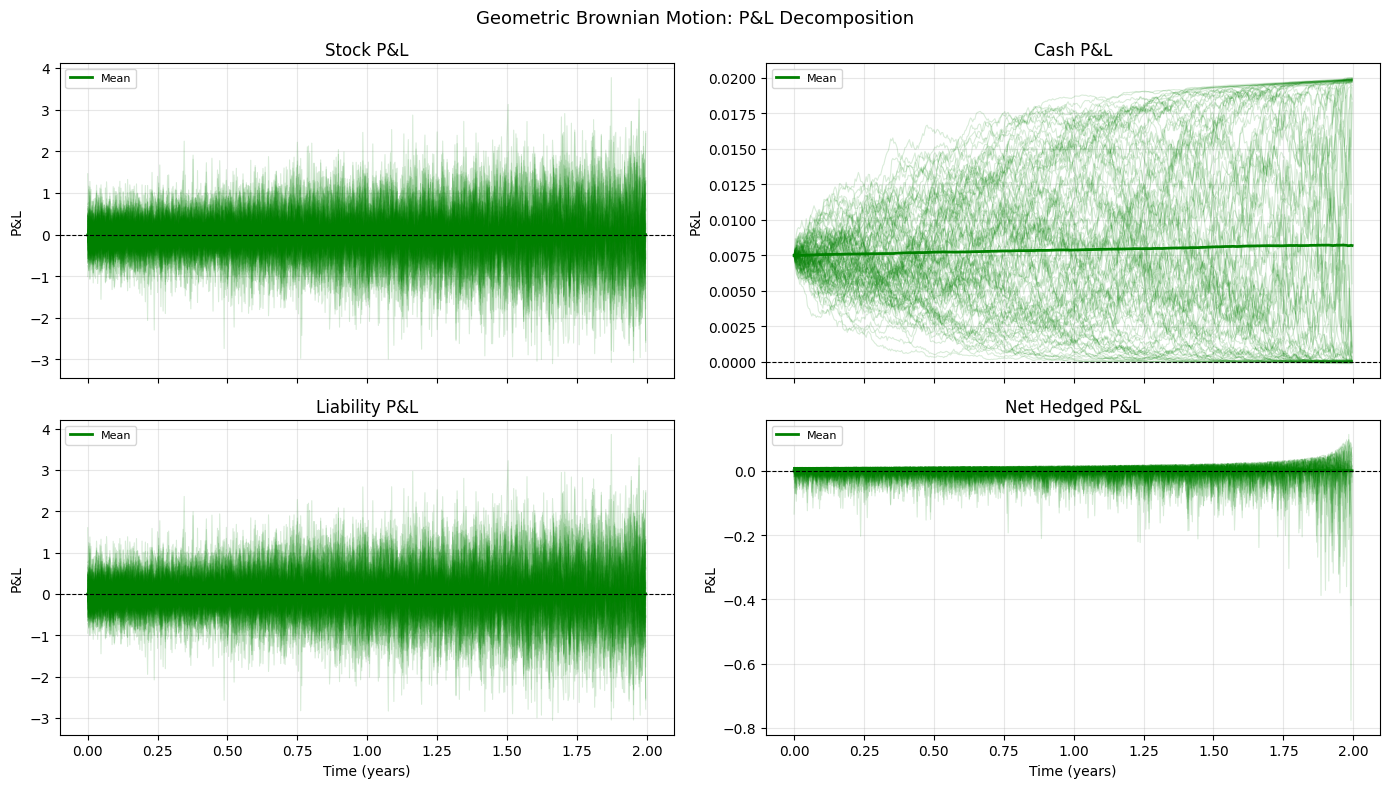

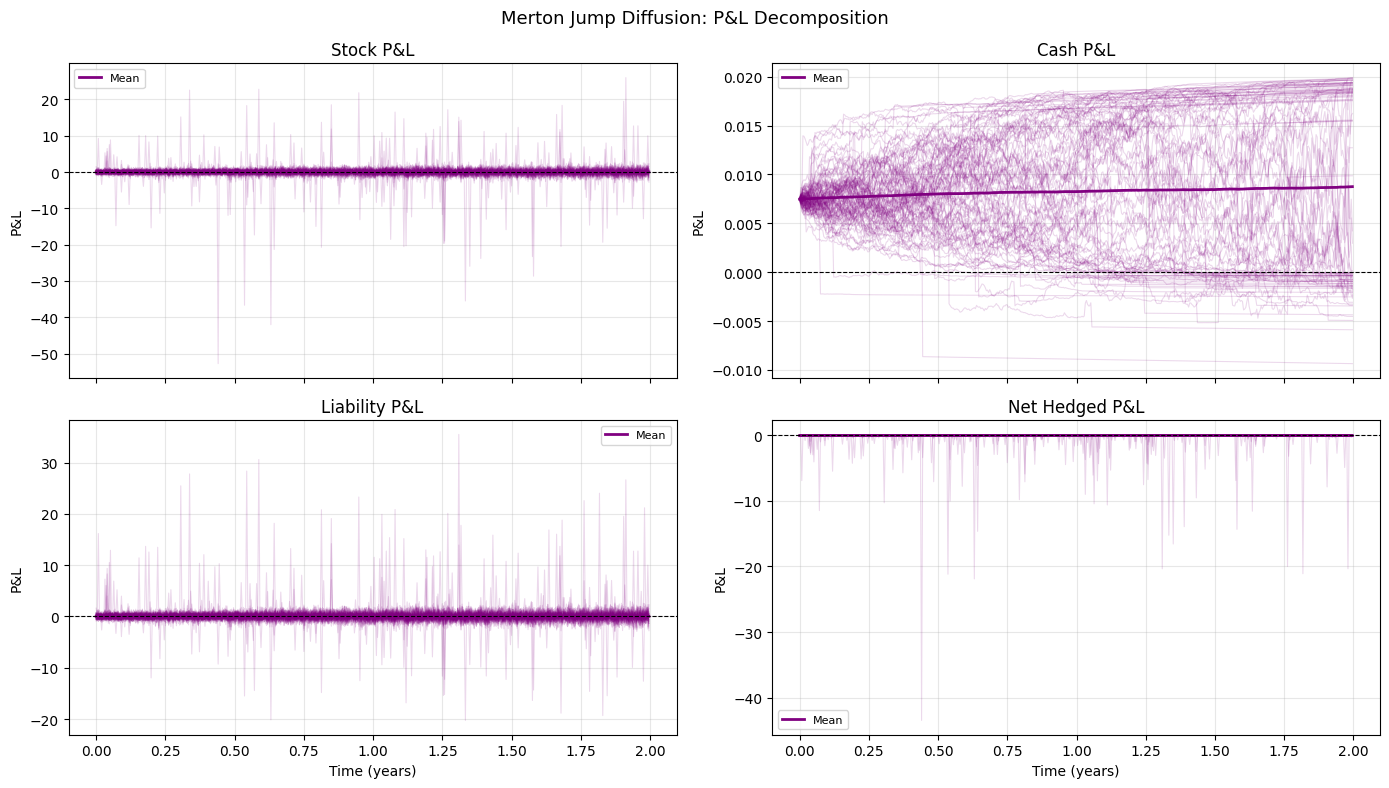

In [9]:
def plot_pnl_decomposition(res: dict, title: str, *, t_grid: np.ndarray, color: str, n_plot: int = 100, seed: int = 42):
    t = t_grid[:-1]

    components = [
        ("Stock P&L",      res["pnl_stock"]),
        ("Cash P&L",       res["pnl_cash"]),
        ("Liability P&L",  res["pnl_liability"]),
        ("Net Hedged P&L", res["pnl_hedged"]),
    ]

    rng = np.random.default_rng(seed)
    n_paths = res["pnl_stock"].shape[0]
    idx = rng.choice(n_paths, size=min(n_plot, n_paths), replace=False)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
    fig.suptitle(title, fontsize=13)

    for ax, (label, data) in zip(axes.flat, components):
        for j in idx:
            ax.plot(t, data[j], color=color, alpha=0.15, lw=0.8)
        ax.plot(t, data.mean(axis=0), lw=2.0, color=color, label="Mean")
        ax.axhline(0, color="black", lw=0.8, ls="--")
        ax.set_title(label)
        ax.set_ylabel("P&L")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    for ax in axes[1]:
        ax.set_xlabel("Time (years)")

    plt.tight_layout()
    plt.show()


plot_pnl_decomposition(gbm_res, "Geometric Brownian Motion: P&L Decomposition", t_grid=t_grid_calendar, color="green")
plot_pnl_decomposition(mjd_res, "Merton Jump Diffusion: P&L Decomposition", t_grid=t_grid_calendar, color="purple")

## Portfolio Path Evolution

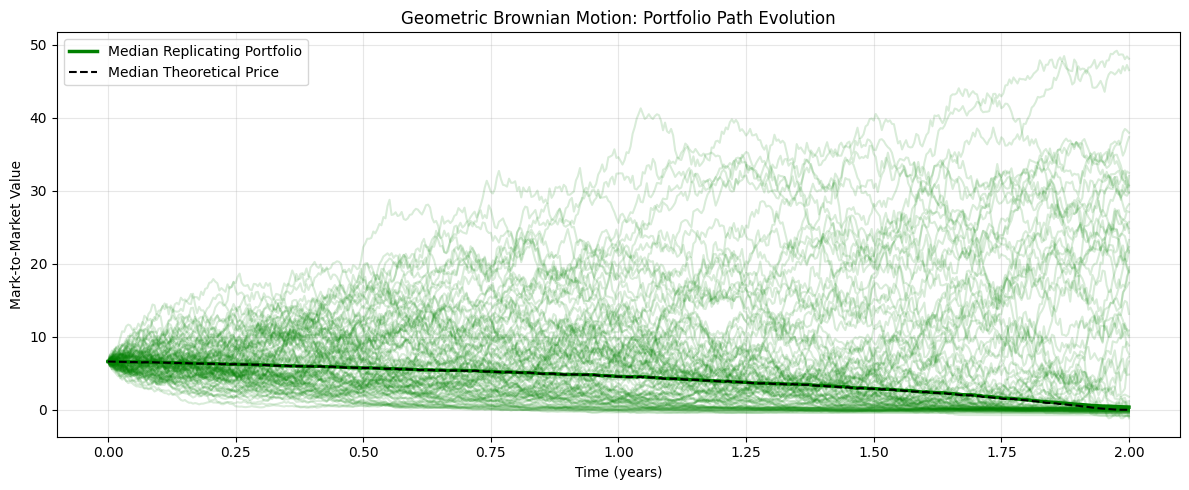

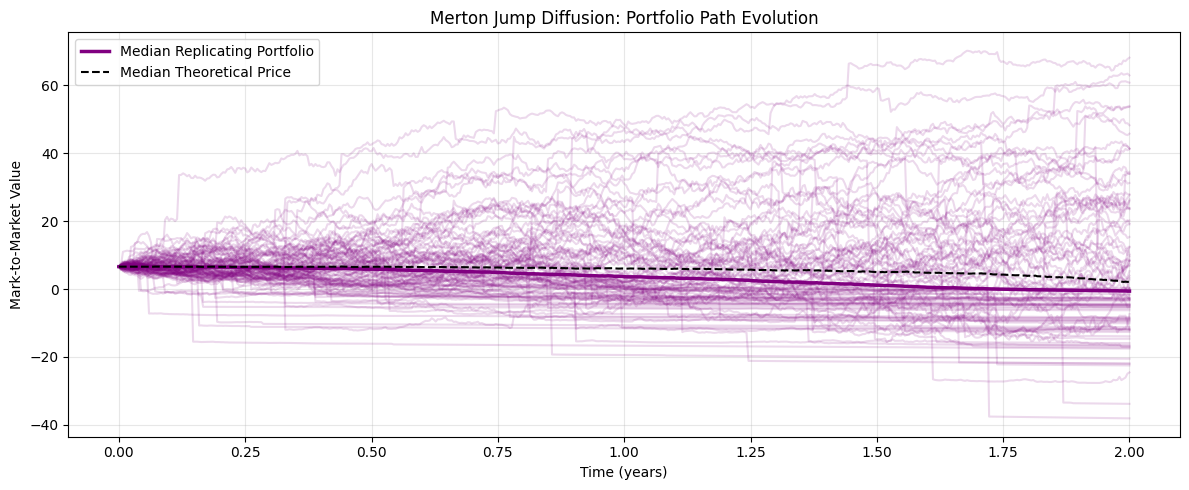

In [10]:
def plot_portfolio_paths(res: dict, title: str, *, t_grid: np.ndarray, color: str, n_plot: int = 100, seed: int = 42):
    rng = np.random.default_rng(seed)
    n_paths = res["V"].shape[0]
    idx = rng.choice(n_paths, size=min(n_plot, n_paths), replace=False)

    V_subset = res["V"][idx]

    plt.figure(figsize=(12, 5))
    
    for j in range(V_subset.shape[0]):
        plt.plot(t_grid, V_subset[j], color=color, alpha=0.15)
    
    plt.plot(t_grid, np.median(res["V"], axis=0), color=color, lw=2.5, 
             label="Median Replicating Portfolio")

    plt.plot(t_grid, np.median(res["C0"], axis=0), color="black", lw=1.5, ls="--", 
             label="Median Theoretical Price")

    plt.title(title)
    plt.xlabel("Time (years)")
    plt.ylabel("Mark-to-Market Value")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_portfolio_paths(gbm_res, "Geometric Brownian Motion: Portfolio Path Evolution", 
                     t_grid=t_grid_calendar, color="green", seed=1)

plot_portfolio_paths(mjd_res, "Merton Jump Diffusion: Portfolio Path Evolution", 
                     t_grid=t_grid_calendar, color="purple", seed=2)